# Pool Ball Detection - Task 1

## Step 1: Initialization and Data Loading
This section imports the allowed libraries and loads the pool table images specified in the input JSON file.

### 1.1 Load Libraries

In [93]:
import json
import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt


### 1.2 Data Ingestion
Reads the JSON input and loads images into a dictionary, converting them to RGB.

In [94]:
json_file = "input.json" 
loaded_images = {}

with open(json_file, 'r') as f:
    data = json.load(f)

image_list = data.get("image_path", []) if isinstance(data, dict) else data

for full_path in image_list:
    img_bgr = cv2.imread(full_path)
    
    if img_bgr is not None:
        clean_name = os.path.basename(full_path)
        
        loaded_images[clean_name] = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"Loaded {len(loaded_images)} images.")

Loaded 50 images.


### 1.3 Sanity Check
Displays 3 random images to verify everything loaded correctly.

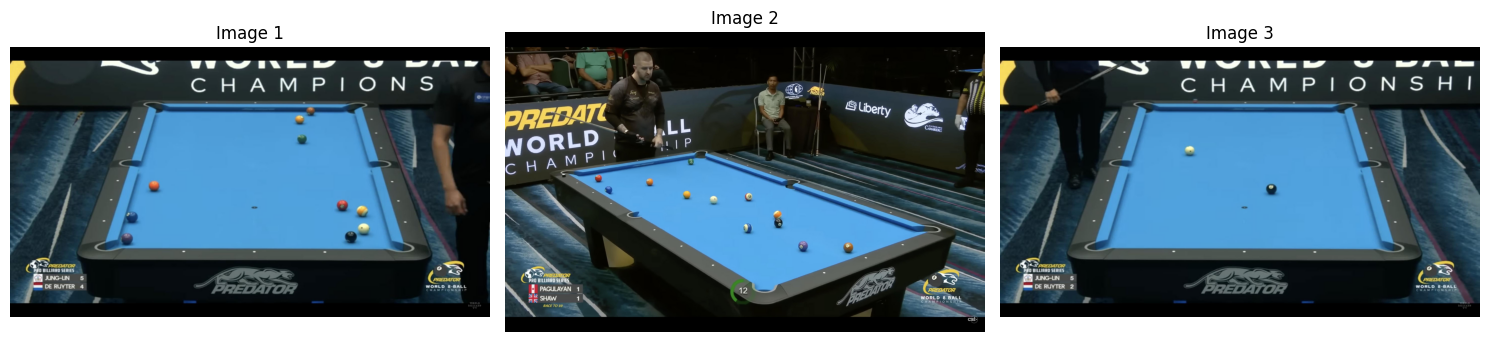

In [95]:
image_paths = list(loaded_images.keys())

first_three_images = image_paths[:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
i = 1
for ax, key in zip(axes, first_three_images):
    ax.imshow(loaded_images[key])
    ax.set_title(f"Image {i}", color='black')
    ax.axis('off')
    i += 1

plt.tight_layout()
plt.show()

## Step 2: Top Down View

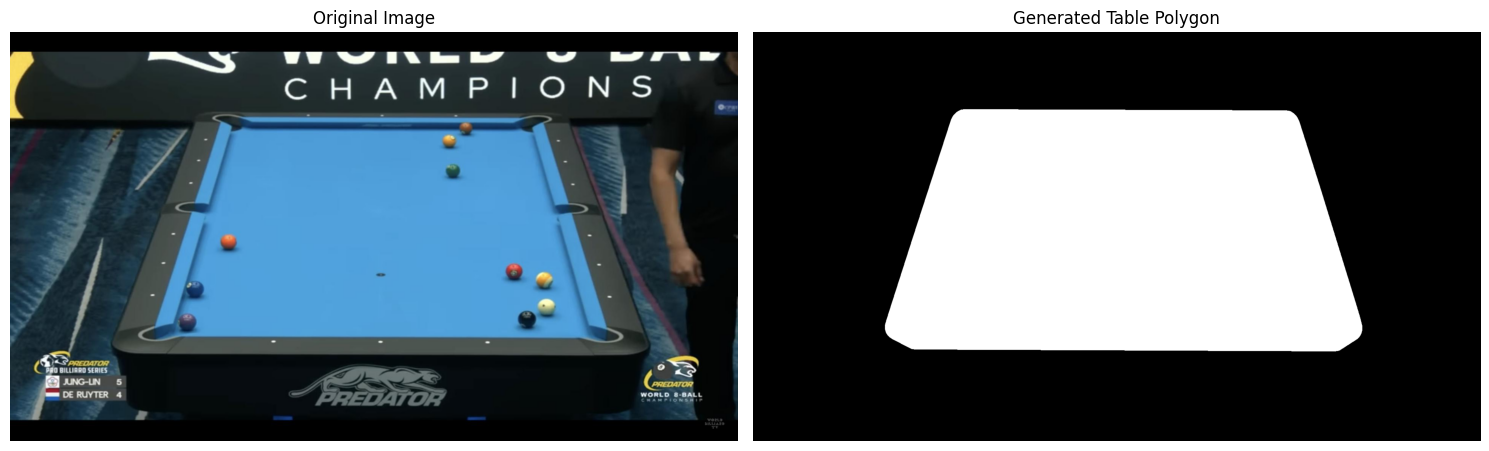

In [118]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════
#  STEP 2 — Table detection 
# ═══════════════════════════════════════════════════════════════

def get_table_mask(image_rgb):
    """
    Finds the playing surface using a tight HSV sample from the image centre,
    then grows + convex-hull to get a clean table polygon.
    Works regardless of camera angle or table lighting.
    """
    img_h, img_w = image_rgb.shape[:2]
    blurred = cv2.GaussianBlur(image_rgb, (7, 7), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)
    cx, cy = img_w // 2, img_h // 2

    # ── 1. Sample cloth colour at image centre ─────────────────────────────
    patch = hsv[cy-60:cy+60, cx-150:cx+150]
    h_med = int(np.median(patch[:, :, 0]))
    s_med = int(np.median(patch[:, :, 1]))
    v_med = int(np.median(patch[:, :, 2]))

    # Tight window — only the brightest, most-saturated cloth pixels
    # This avoids picking up banners, carpet, or spectator clothing
    core = cv2.inRange(hsv,
        (max(0,   h_med - 12), max(60, s_med - 50), max(100, v_med - 60)),
        (min(180, h_med + 12), 255, 255))

    # ── 2. Pick the blob that contains the frame centre ────────────────────
    cnts, _ = cv2.findContours(core, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return np.zeros((img_h, img_w), dtype=np.uint8)

    table_cnt = None
    for c in sorted(cnts, key=cv2.contourArea, reverse=True)[:5]:
        if cv2.pointPolygonTest(c, (cx, cy), False) >= 0:
            table_cnt = c
            break
    if table_cnt is None:
        table_cnt = max(cnts, key=cv2.contourArea)

    # ── 3. Dilate to fill ball-holes & shadow gaps ─────────────────────────
    seed = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.drawContours(seed, [table_cnt], -1, 255, cv2.FILLED)
    k = max(25, img_w // 50)
    seed = cv2.dilate(seed,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k*2+1, k*2+1)), iterations=2)

    # ── 4. Convex hull → clean table polygon ──────────────────────────────
    cnts2, _ = cv2.findContours(seed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    hull = cv2.convexHull(max(cnts2, key=cv2.contourArea))
    poly = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.fillPoly(poly, [hull], 255)

    # ── 5. Erode slightly to cut off rails/cushions ────────────────────────
    ep = max(4, int(min(img_h, img_w) * 0.020))
    poly = cv2.erode(poly,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ep*2+1, ep*2+1)), iterations=2)

    return poly

# --- Visualization Preview ---
if len(loaded_images) > 0:
    image_paths = list(loaded_images.keys())
    test_key = image_paths[0]  
    test_img = loaded_images[test_key]

    mask = get_table_mask(test_img)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    ax1.imshow(test_img)
    ax1.set_title("Original Image", color='black')
    ax1.axis('off')

    ax2.imshow(mask, cmap='gray')
    ax2.set_title("Generated Table Polygon", color='black')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No images loaded.")

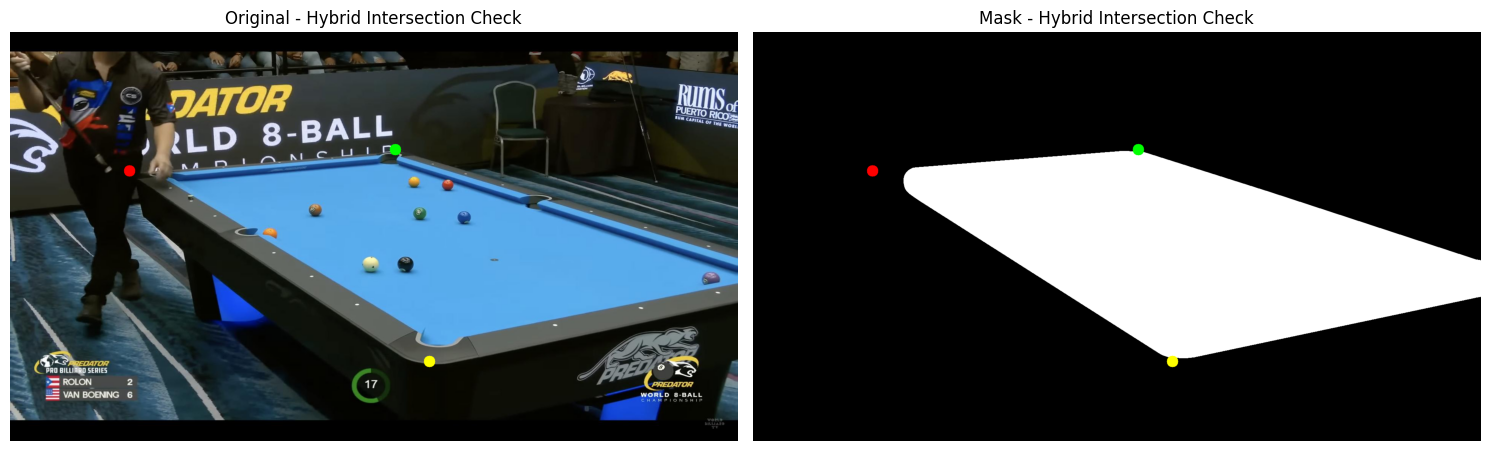

In [124]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def order_points_clockwise(pts):
    """Sorts corners bulletproofly using geometry (angles from center)."""
    cx, cy = np.mean(pts, axis=0)
    angles = np.arctan2(pts[:, 1] - cy, pts[:, 0] - cx)
    sorted_pts = pts[np.argsort(angles)]
    
    s = sorted_pts.sum(axis=1)
    tl_index = np.argmin(s)
    return np.roll(sorted_pts, shift=-tl_index, axis=0)

def intersect_lines(l1, l2):
    """Calculates the exact (x, y) intersection of two line vectors."""
    vx1, vy1, x1, y1 = l1
    vx2, vy2, x2, y2 = l2
    
    # Line equations: Ax + By = C
    A1, B1 = vy1, -vx1
    C1 = vy1 * x1 - vx1 * y1
    
    A2, B2 = vy2, -vx2
    C2 = vy2 * x2 - vx2 * y2
    
    det = A1 * B2 - A2 * B1
    if abs(det) < 1e-6:
        return None # Parallel
        
    x = (C1 * B2 - C2 * B1) / det
    y = (A1 * C2 - A2 * C1) / det
    return [x, y]

def get_corners_from_mask(table_mask):
    """
    Hybrid Method: Uses approxPolyDP to identify the 4 sides, 
    trims the rounded corners, fits mathematically perfect lines, and intersects them.
    """
    cnts, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return None
        
    largest_contour = max(cnts, key=cv2.contourArea)
    peri = cv2.arcLength(largest_contour, True)
    
    # 1. Use your working approxPolyDP to get the 4 "Guidepost" corners
    guide_corners = None
    for eps_multiplier in np.linspace(0.005, 0.2, 100):
        epsilon = eps_multiplier * peri
        approx = cv2.approxPolyDP(largest_contour, epsilon, True)
        if len(approx) == 4 and cv2.isContourConvex(approx):
            guide_corners = approx.reshape(4, 2).astype("float32")
            break
            
    if guide_corners is None: return None
    
    # Order the guideposts: 0:TL, 1:TR, 2:BR, 3:BL
    ordered_guides = order_points_clockwise(guide_corners)
    
    # 2. Extract every pixel along the contour boundary
    pts = largest_contour.reshape(-1, 2)
    edge_points = [[], [], [], []]
    
    # 3. Assign every pixel to one of the 4 edges
    for pt in pts:
        min_dist = float('inf')
        best_edge = -1
        for i in range(4):
            p1 = ordered_guides[i]
            p2 = ordered_guides[(i + 1) % 4]
            # Distance from point to line segment
            l2 = np.sum((p1 - p2)**2)
            if l2 == 0: continue
            t = max(0, min(1, np.dot(pt - p1, p2 - p1) / l2))
            proj = p1 + t * (p2 - p1)
            dist = np.linalg.norm(pt - proj)
            if dist < min_dist:
                min_dist = dist
                best_edge = i
        edge_points[best_edge].append(pt)
        
    # 4. Fit a perfect line to each edge, IGNORING the rounded corners
    fitted_lines = []
    for i in range(4):
        ep = np.array(edge_points[i])
        if len(ep) < 10: return None
        
        # Sort points by distance from the start corner to easily trim the ends
        p1 = ordered_guides[i]
        dists = np.linalg.norm(ep - p1, axis=1)
        ep_sorted = ep[np.argsort(dists)]
        
        # Throw away 15% of pixels at both ends (the curved erosion artifacts)
        trim = int(len(ep_sorted) * 0.15)
        if trim > 0:
            ep_trimmed = ep_sorted[trim:-trim]
        else:
            ep_trimmed = ep_sorted
            
        # Fit infinite line
        [vx, vy, x, y] = cv2.fitLine(ep_trimmed, cv2.DIST_L2, 0, 0.01, 0.01)
        fitted_lines.append((vx[0], vy[0], x[0], y[0]))
        
    # 5. Intersect the 4 lines to get the sharp, true geometric corners
    tl = intersect_lines(fitted_lines[0], fitted_lines[3]) # Top intersects Left
    tr = intersect_lines(fitted_lines[0], fitted_lines[1]) # Top intersects Right
    br = intersect_lines(fitted_lines[1], fitted_lines[2]) # Right intersects Bottom
    bl = intersect_lines(fitted_lines[2], fitted_lines[3]) # Bottom intersects Left
    
    if None in (tl, tr, br, bl): return None
    
    return np.array([tl, tr, br, bl], dtype="float32")

# --- Diagnostic Visualization ---
if len(loaded_images) > 0:
    image_paths = list(loaded_images.keys())
    
    # Change the index to test your specific oblique images!
    test_key = "129_png.rf.eb2bbec526ed5285770c494673de2c04.jpg"
    test_img = loaded_images[test_key].copy()
    
    test_mask = get_table_mask(test_img)
    test_mask_rgb = cv2.cvtColor(test_mask, cv2.COLOR_GRAY2RGB)
    
    raw_corners = get_corners_from_mask(test_mask)
    
    if raw_corners is not None:
        ordered_corners = order_points_clockwise(raw_corners)
        colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]
        
        for i, pt in enumerate(ordered_corners):
            x, y = int(pt[0]), int(pt[1])
            cv2.circle(test_img, (x, y), 15, colors[i], -1)
            cv2.circle(test_mask_rgb, (x, y), 15, colors[i], -1)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

        ax1.imshow(test_img)
        ax1.set_title("Original - Hybrid Intersection Check", color='black')
        ax1.axis('off')

        ax2.imshow(test_mask_rgb)
        ax2.set_title("Mask - Hybrid Intersection Check", color='black')
        ax2.axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("Could not find 4 corners in the mask.")
else:
    print("No images loaded.")

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════
#  STEP 3 — Corner Extraction & Top-Down Warp
# ═══════════════════════════════════════════════════════════════

def order_points_clockwise(pts):
    """Sorts corners bulletproofly using geometry (angles from center)."""
    cx, cy = np.mean(pts, axis=0)
    angles = np.arctan2(pts[:, 1] - cy, pts[:, 0] - cx)
    sorted_pts = pts[np.argsort(angles)]
    
    s = sorted_pts.sum(axis=1)
    tl_index = np.argmin(s)
    return np.roll(sorted_pts, shift=-tl_index, axis=0)

def warp_to_top_down(image_rgb, ordered_corners, width=1200, height=800):
    """
    Warps the 4 corners into a perfect horizontal top-down view.
    Uses a foreshortening ratio to correctly fix stretched oblique angles.
    """
    top_edge = np.linalg.norm(ordered_corners[0] - ordered_corners[1])
    left_edge = np.linalg.norm(ordered_corners[0] - ordered_corners[3])
    
    ratio = top_edge / left_edge
    
    if ratio < 2.2:
        # END-VIEW mapping
        dst_pts = np.array([
            [0, 0],                  
            [0, height - 1],         
            [width - 1, height - 1], 
            [width - 1, 0]           
        ], dtype="float32")
    else:
        # SIDE-VIEW mapping
        dst_pts = np.array([
            [0, 0],                  
            [width - 1, 0],          
            [width - 1, height - 1], 
            [0, height - 1]          
        ], dtype="float32")

    M = cv2.getPerspectiveTransform(ordered_corners, dst_pts)

    # Add borderMode=cv2.BORDER_REPLICATE to prevent black borders in extreme warps
    # This is not necessary but can make the images look nicer.
    warped = cv2.warpPerspective(image_rgb, M, (width, height), borderMode=cv2.BORDER_REPLICATE)
    
    return warped, M

# ═══════════════════════════════════════════════════════════════
#  BATCH PROCESSING & SAVING
# ═══════════════════════════════════════════════════════════════

output_folder = "output"
os.makedirs(output_folder, exist_ok=True)

print(f"Starting batch process. Saving top-down images to '{output_folder}'...")

success_count = 0
fail_count = 0

# Assuming loaded_images and get_table_mask are defined earlier in your notebook
for filename, img_rgb in loaded_images.items():
    test_mask = get_table_mask(img_rgb)
    raw_corners = get_corners_from_mask(test_mask)
    
    if raw_corners is not None:
        ordered_corners = order_points_clockwise(raw_corners)
        warped_img, _ = warp_to_top_down(img_rgb, ordered_corners)
        
        # Convert RGB back to BGR so OpenCV saves the colors correctly
        warped_bgr = cv2.cvtColor(warped_img, cv2.COLOR_RGB2BGR)
        
        save_path = os.path.join(output_folder, filename)
        cv2.imwrite(save_path, warped_bgr)
        
        success_count += 1
    else:
        print(f"Warning: Could not find corners for {filename}")
        fail_count += 1

print(f"Batch complete! Successfully warped and saved {success_count} images. ({fail_count} failed)")

Starting batch process. Saving top-down images to 'output'...
Batch complete! Successfully warped and saved 50 images. (0 failed)
